# Model Building

In [5]:
%load_ext autoreload
%autoreload 2

In [60]:
import torch 
import numpy as np
import pandas as pd
from torch.utils.data import  DataLoader, Subset
from sklearn.model_selection import KFold, train_test_split
from torchmetrics import Accuracy, Precision, Recall, F1Score,AUROC
import data_loading
from tqdm import tqdm
import itertools
import random

In [61]:
# check if there is GPU support 
if torch.cuda.is_available():
    print("CUDA is available! 🥳")
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU: {torch.cuda.get_device_name(0  )}") # Check the name of the first GPU
else:
    print("CUDA is not available. 😟")


CUDA is available! 🥳
CUDA version: 12.6
Number of GPUs: 1
Current GPU: NVIDIA GeForce GTX 1650 Ti


In [62]:
random_seed_picked = 31
random_seed_picked

31

In [63]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [64]:
set_seed(random_seed_picked)

## 1. Data Loading

In [65]:
NLST_dataset = data_loading.NLSTDataset('final_preprocessed_datasets/lung_cancer_detection_segmented.h5','Lung_Cancer_multimodal_patient_EHR.csv',data_loading.train_transforms)

Loading Data....
Loading Done!


In [39]:
for X_data,label in NLST_dataset:
    print(X_data,label)
    break

{'image': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]]), 'table': tensor([ 1.,  1.,  2., 61.])} tensor(1)


In [40]:
X_data['table'].dtype

torch.float32

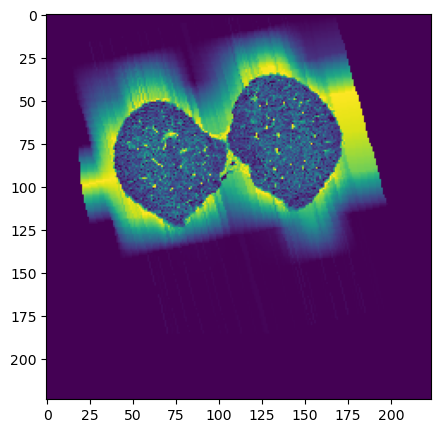

In [41]:
data_loading.print_dicomNM(X_data['image'][0],1,1,figsize=(5,5))

In [42]:
NLST_dataset_test = data_loading.NLSTDataset('final_preprocessed_datasets/lung_cancer_detection_segmented.h5','Lung_Cancer_multimodal_patient_EHR.csv')

Loading Data....
Loading Done!


In [43]:
for X_data,label in NLST_dataset_test:
    print(X_data,label)
    break

{'image': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]]), 'table': tensor([ 1.,  1.,  2., 61.])} tensor(1)


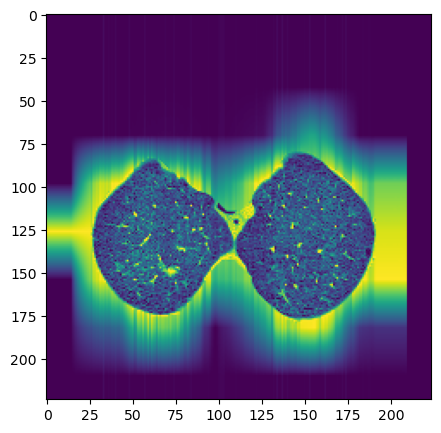

In [44]:
data_loading.print_dicomNM(X_data['image'][0],1,1,figsize=(5,5))

In [45]:
NLST_dataset.__len__()

14278

In [46]:
(NLST_dataset.__len__() / 10) / NLST_dataset.__len__()

0.09999999999999999

In [47]:
lung_cancer_labels = np.load('final_preprocessed_datasets/lung_cancer_detection_labels.npy')

In [48]:
len(lung_cancer_labels)

14278

In [49]:
NLST_dataloaders = DataLoader(NLST_dataset,batch_size=4,shuffle=True)

In [50]:
lung_cancer_labels.__len__()

14278

In [51]:
# test
for X_data,label in NLST_dataloaders:
    print(X_data,label)
    break

{'image': tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.3307, 0.3320, 0.3022,  ..., 0.0327, 0.0230, 0.0173],
          [0.3491, 0.3484, 0.3157,  ..., 0.0341, 0.0240, 0.0180],
          [0.3676, 0.3651, 0

In [23]:
X_data['table'].shape

torch.Size([4, 4])

In [19]:
X_data['image'].dtype

torch.float32

Table Data: tensor([[ 1.,  1.,  2., 55.],
        [ 1.,  1.,  2., 60.]])
Y_labels: tensor([0, 0])


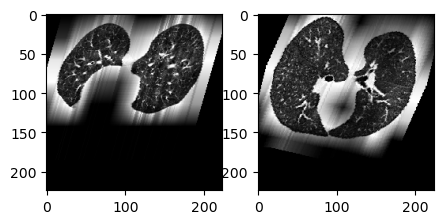

In [ ]:
data_loading.print_dicomNM(X_data['image'][2:],1,2,figsize=(5,5))
print("Table Data:",X_data['table'][2:])
print("Y_labels:",label[2:])

In [18]:
NLST_dataloaders_test = DataLoader(NLST_dataset_test,batch_size=4,shuffle=False)

In [26]:
for X_data,label in NLST_dataloaders_test:
    print(X_data,label)
    break

{'image': tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0.,

Table Data: tensor([[ 1.,  1.,  2., 61.],
        [ 1.,  1.,  2., 61.],
        [ 1.,  1.,  2., 61.],
        [ 1.,  1.,  2., 61.]])
Y_labels: tensor([1, 1, 1, 1])


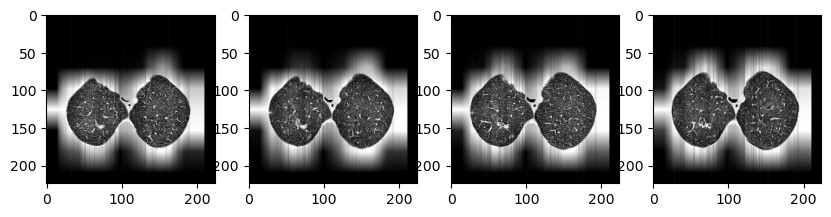

In [27]:
data_loading.print_dicomNM(X_data['image'],1,4,figsize=(10,10))
print("Table Data:",X_data['table'])
print("Y_labels:",label)

In [24]:
indices = np.arange(len(NLST_dataset))


In [25]:
# 80-10-10 train-test split
train_val_idx, test_idx, y_train_val, y_test = train_test_split(
    indices,lung_cancer_labels, test_size=0.10, random_state=random_seed_picked, stratify=lung_cancer_labels
)


In [26]:
(train_val_idx[:5],test_idx[:5])

(array([ 9287,  5174,  6153,  2019, 12464]),
 array([9245, 2890, 7137,  309, 2655]))

In [27]:
(len(train_val_idx),len(test_idx))

(12850, 1428)

## 2. Models

### 2.2 IMPROVED ENCODERS AND MULTIMODAL ATTENTION HEAD FOR INTERMEDIATE MULTIMODAL FUSION

In [57]:
import torch.nn as nn
from torchvision import models
from IPython.display import clear_output

#### 2.2.1 Pre train EHR Autoencoder

In [28]:
import pandas as pd
import numpy as np

In [29]:
Lung_cancer_EHR_training =pd.read_csv("Lung_Cancer_training_EHR.csv").iloc[:,1:-1].reset_index(drop=True).to_numpy()
Lung_cancer_EHR_training

array([[ 1,  1,  1, 66],
       [ 1,  1,  2, 56],
       [ 1,  1,  2, 56],
       ...,
       [ 1,  1,  2, 73],
       [ 1,  0,  1, 69],
       [ 1,  1,  1, 57]], dtype=int64)

In [30]:
Lung_cancer_Mulimodal = pd.read_csv("Lung_Cancer_multimodal_patient_EHR.csv").iloc[:,1:-1].reset_index(drop=True).to_numpy()
Lung_cancer_Mulimodal

array([[ 1,  1,  2, 61],
       [ 1,  0,  1, 68],
       [ 1,  0,  1, 65],
       ...,
       [ 1,  1,  2, 61],
       [ 1,  0,  2, 58],
       [ 1,  0,  2, 65]], dtype=int64)

In [31]:
def sample_to_cat(sample):
    decimals = np.array(sample) % 1
    new_sample = []
    for index,value in enumerate(sample):
        if decimals[index] >= 0.5:
            new_sample.append(np.ceil(value))
        else:
            new_sample.append(np.floor(value))
    return np.array(new_sample)


In [55]:
class EHRDataset(torch.utils.data.Dataset):
    def __init__(self,tabular_data):
        self.data = torch.tensor(tabular_data,dtype=torch.float32)
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        return item

In [58]:
class EHRDeepAutoencoder(nn.Module):
    def __init__(self, input_dim=4, latent_dim=16):
        super(EHRDeepAutoencoder, self).__init__()
        
        # Encoder: 4 -> 16 -> 8 -> 2
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim) # The bottleneck
        )
        
        # Decoder: 2 -> 8 -> 16 -> 4
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
        )

        self.decoder_conversion = nn.Sequential(
            nn.ReLU(),
            nn.Linear(16, input_dim) # Output layer has no activation
        )

    def forward(self, x,feature_matrix = False):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        if feature_matrix:
            return decoded
        decoded = self.decoder_conversion(decoded)
        return decoded

In [67]:
batch_size = 1000
EHR_dataset = EHRDataset(Lung_cancer_EHR_training)
EHR_dataloader = DataLoader(EHR_dataset, batch_size=batch_size, shuffle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- 4. Training Configuration ---
input_dim = 4 # Should be 4
latent_dim = 16 # The size of our compressed representation
learning_rate = 0.0001
num_epochs = 100

Using device: cuda


In [24]:
EHR_model = EHRDeepAutoencoder(input_dim, latent_dim).to(device)
EHR_criterion = nn.MSELoss() # Mean Squared Error for reconstruction loss
EHR_optimizer = torch.optim.Adam(EHR_model.parameters(), lr=learning_rate)

In [194]:
EHR_model.state_dict()

OrderedDict([('encoder.0.weight',
              tensor([[-0.1808,  0.2404, -0.3692,  0.3610],
                      [ 0.3897,  0.4627,  0.3059,  0.3110],
                      [-0.1319, -0.4897, -0.1611, -0.1911],
                      [-0.2665, -0.4763,  0.2855,  0.3905],
                      [ 0.1909,  0.3896, -0.0823,  0.1030],
                      [-0.0058, -0.0361, -0.1229,  0.4840],
                      [ 0.1321,  0.4837,  0.1989, -0.2972],
                      [-0.2731,  0.4995,  0.0018, -0.3198],
                      [-0.2932,  0.0378, -0.4309,  0.1593],
                      [-0.1712,  0.1475, -0.1002, -0.1145],
                      [-0.1961,  0.0232, -0.1600, -0.4890],
                      [-0.0801, -0.0634, -0.2324, -0.1603],
                      [ 0.1823,  0.4375,  0.1659,  0.2998],
                      [-0.2457, -0.4726,  0.4701, -0.1492],
                      [-0.4513,  0.2543,  0.0259, -0.2872],
                      [ 0.4945, -0.2729,  0.3068, -0.4943]], devic

In [195]:
# --- 5. The Training Loop ---
train_losses = []
print("Starting training...")
for epoch in range(num_epochs):
    epoch_loss = 0
    for data in EHR_dataloader:
        # Get a batch of data
        batch_features = data.to(device)
        
        # Forward pass
        reconstructed = EHR_model(batch_features)
        
        # Calculate the loss
        loss = EHR_criterion(reconstructed, batch_features)
        
        # Backward pass and optimization
        EHR_optimizer.zero_grad()
        loss.backward()
        EHR_optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_epoch_loss = epoch_loss / len(EHR_dataloader)
    train_losses.append(avg_epoch_loss)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_epoch_loss:.6f}')
        
print("Training complete.")


Starting training...
Epoch [10/100], Loss: 296.880529
Epoch [20/100], Loss: 4.731981
Epoch [30/100], Loss: 4.514398
Epoch [40/100], Loss: 4.328090
Epoch [50/100], Loss: 4.274598
Epoch [60/100], Loss: 4.206112
Epoch [70/100], Loss: 4.099047
Epoch [80/100], Loss: 3.590040
Epoch [90/100], Loss: 1.160389
Epoch [100/100], Loss: 0.188302
Training complete.


In [81]:
EHR_model.state_dict()

OrderedDict([('encoder.0.weight',
              tensor([[-1.4746e-01, -2.4656e-01, -8.5025e-03, -1.5882e-01],
                      [-2.1005e-01,  1.6715e-01, -1.6618e-01, -2.2273e-01],
                      [-3.6413e-01,  3.8640e-02,  1.0668e-01, -4.1408e-01],
                      [-4.8681e-01,  5.5541e-02,  9.1942e-02, -4.0500e-01],
                      [-4.6946e-01, -3.2350e-01, -1.7484e-01, -2.5476e-01],
                      [-3.1761e-01, -2.2522e-01, -5.5954e-02, -1.6850e-02],
                      [ 1.6236e-01,  6.3074e-02,  1.1537e-02,  5.9072e-01],
                      [ 2.5877e-01,  2.0994e-01,  4.2936e-01,  2.4229e-01],
                      [-3.6966e-01,  2.0877e-01,  3.6620e-02, -3.7754e-01],
                      [-4.2005e-01,  4.5980e-01,  2.4576e-01, -4.8915e-01],
                      [-4.9845e-01, -1.5618e-01,  5.5480e-02,  3.1504e-01],
                      [-4.3054e-01, -4.4948e-01, -7.8430e-02,  2.1340e-01],
                      [-1.8432e-01, -1.3792e-01,  3.31

In [82]:
# --- 6. Evaluation and Visualization ---
EHR_model.eval() # Set the model to evaluation mode

# Take one sample from our dataset to test reconstruction
sample_idx = 100
original_sample = torch.Tensor(Lung_cancer_Mulimodal[sample_idx]).to(device) # Add batch dimension

# Get the reconstruction from the model
with torch.no_grad():
    reconstructed_sample = EHR_model(original_sample)

# Move tensors to CPU and convert to numpy for display/plotting
original_np = original_sample.cpu().numpy().flatten()
reconstructed_np = sample_to_cat(reconstructed_sample.cpu().numpy())
print(original_np)
print(reconstructed_np)

[ 1.  1.  1. 60.]
[ 1.  0.  1. 60.]


In [83]:
torch.save(EHR_model.state_dict(),"multi_modal_models/EHR_self_trained.pth")

In [34]:
pretrained_vision_encoder = EHRDeepAutoencoder(4,16)
pretrained_vision_encoder.load_state_dict(torch.load("multi_modal_models/EHR_self_trained.pth"))

<All keys matched successfully>

In [36]:
pretrained_vision_encoder.state_dict()

OrderedDict([('encoder.0.weight',
              tensor([[-1.4746e-01, -2.4656e-01, -8.5025e-03, -1.5882e-01],
                      [-2.1005e-01,  1.6715e-01, -1.6618e-01, -2.2273e-01],
                      [-3.6413e-01,  3.8640e-02,  1.0668e-01, -4.1408e-01],
                      [-4.8681e-01,  5.5541e-02,  9.1942e-02, -4.0500e-01],
                      [-4.6946e-01, -3.2350e-01, -1.7484e-01, -2.5476e-01],
                      [-3.1761e-01, -2.2522e-01, -5.5954e-02, -1.6850e-02],
                      [ 1.6236e-01,  6.3074e-02,  1.1537e-02,  5.9072e-01],
                      [ 2.5877e-01,  2.0994e-01,  4.2936e-01,  2.4229e-01],
                      [-3.6966e-01,  2.0877e-01,  3.6620e-02, -3.7754e-01],
                      [-4.2005e-01,  4.5980e-01,  2.4576e-01, -4.8915e-01],
                      [-4.9845e-01, -1.5618e-01,  5.5480e-02,  3.1504e-01],
                      [-4.3054e-01, -4.4948e-01, -7.8430e-02,  2.1340e-01],
                      [-1.8432e-01, -1.3792e-01,  3.31

In [138]:
# --- 7. Evaluation and Visualization for saved weights ---
pretrained_vision_encoder.eval() # Set the model to evaluation mode

# Take one sample from our dataset to test reconstruction
sample_idx = 200
original_sample = torch.Tensor(Lung_cancer_Mulimodal[sample_idx]) # Add batch dimension

# Get the reconstruction from the model
with torch.no_grad():
    reconstructed_sample = pretrained_vision_encoder(original_sample)
    reconstructed_sample_feature = pretrained_vision_encoder(original_sample,feature_matrix=True)


# Move tensors to CPU and convert to numpy for display/plotting
original_np = original_sample.cpu().numpy().flatten()
reconstructed_np = sample_to_cat(reconstructed_sample.cpu().numpy())
print(original_np)
print(reconstructed_np)
print(reconstructed_sample_feature)

[ 1.  1.  2. 55.]
[ 1.  1.  2. 55.]
tensor([-28.6566, -29.4693,  -8.1273,  63.5900, -13.1478,  -8.5626, -27.4289,
        -15.9002,  61.8606, -12.0386, -22.2502, -11.8266,   2.1051,  61.9422,
         -4.6162,  60.5499])


#### 2.2.2 Image Encoder

In [68]:
def get_resnet_model_for_1_channel(resnet_model,weights):
    """
    Loads a pre-trained ResNet-50, adapts its first layer for 1-channel
    (grayscale) input, and replaces the final classification layer.
    """
    # Load a pre-trained ResNet-50 model
    model = resnet_model(weights = weights)

    # --- MODIFICATION FOR 1-CHANNEL INPUT ---
    # 1. Get the original weights of the first convolutional layer
    original_weights = model.conv1.weight.clone()

    # 2. Create a new convolutional layer with 1 input channel
    new_conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    
    # 3. Adapt the pre-trained weights from 3 channels to 1
    # We do this by averaging the weights across the 3 RGB channels.
    with torch.no_grad():
        new_conv1.weight[:,:] = torch.sum(original_weights, dim=1, keepdim=True)

    # 4. Replace the original conv1 layer with the new one
    model.conv1 = new_conv1
    
    # --- END OF MODIFICATION ---
    


    # Replace the final classification layer for our specific task
    model.fc = nn.Identity()

    return model
    

In [15]:
IMG_model = get_resnet_model_for_1_channel(models.resnet34,weights=models.ResNet34_Weights.IMAGENET1K_V1)
IMG_model

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [39]:
EHR_model.decoder[2].out_features

16

In [40]:
IMG_model.layer4[2].bn2.num_features


512

#### 2.2.3 Multimodal Head

In [70]:
class MultimodalAttentionClassifier(nn.Module):
    def __init__(self, clinical_ehr_model, image_model, num_heads=4):
        super(MultimodalAttentionClassifier, self).__init__()
        
        # --- Feature Extractors ---
        self.clinical_model = clinical_ehr_model
        self.image_model = image_model
        clinical_encoding_dim = clinical_ehr_model.decoder[2].out_features
        image_feature_dim =[child for child in image_model.layer4[-1].children() if type(child) == torch.nn.modules.conv.Conv2d][-1].out_channels
        
        # --- Co-Attention Mechanism ---
        # Clinical data attends to image data
        self.img_attention = nn.MultiheadAttention(
            embed_dim=clinical_encoding_dim, 
            kdim=image_feature_dim, 
            vdim=image_feature_dim, 
            num_heads=num_heads, 
            batch_first=True # Makes handling batch dimensions easier
        )
        
        # Image data attends to clinical data
        self.clin_attention = nn.MultiheadAttention(
            embed_dim=image_feature_dim, 
            kdim=clinical_encoding_dim, 
            vdim=clinical_encoding_dim, 
            num_heads=num_heads, 
            batch_first=True
        )

        # --- Classifier Head ---
        # The input size is the sum of the two original feature dimensions
        fused_dim = clinical_encoding_dim + image_feature_dim
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, fused_dim // 2),
            nn.ReLU(),
            nn.Linear(fused_dim // 2, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16, 2),
              # 2 classes: cancer / no cancer 
        )

    def forward(self, clinical_data, image_data):
        # 1. Extract features from both modalities
        clinical_features = self.clinical_model(clinical_data,feature_matrix=True) # Shape: (batch_size, clinical_encoding_dim)
        
        image_features_raw = self.image_model(image_data)
        image_features = torch.flatten(image_features_raw, 1) # Shape: (batch_size, image_feature_dim)

        # 2. Reshape features for the attention layer (add a sequence dimension)
        clin_q = clinical_features.unsqueeze(1) # Shape: (batch_size, 1, clinical_encoding_dim)
        img_kv = image_features.unsqueeze(1)   # Shape: (batch_size, 1, image_feature_dim)
        
        img_q = image_features.unsqueeze(1)    # Shape: (batch_size, 1, image_feature_dim)
        clin_kv = clinical_features.unsqueeze(1) # Shape: (batch_size, 1, clinical_encoding_dim)

        # 3. Apply co-attention
        # Get image features weighted by clinical relevance
        attended_img, _ = self.img_attention(query=clin_q, key=img_kv, value=img_kv)
        
        # Get clinical features weighted by image relevance
        attended_clin, _ = self.clin_attention(query=img_q, key=clin_kv, value=clin_kv)

        # 4. Squeeze out the sequence dimension
        attended_img = attended_img.squeeze(1)
        attended_clin = attended_clin.squeeze(1)

        # 5. Concatenate the attended features and classify
        fused_features = torch.cat((attended_clin, attended_img), dim=1)
        output = self.classifier(fused_features)
        
        return output

### 2.3 FIRST INTERMEDIATE MODEL: Pretrained Self Made Autoencoder, Resnet32, Multiattention Head

In [52]:
best_f1 = -1
best_params = None
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_SPLITS = 10 # 10-fold CV for tuning

param_grid = {
    'learning_rate': [0.001, 0.0001],
    'batch_size': [50],
    'epochs': [10,15],
    'epsilon': [1e-8, 1e-7],
}


# --- 4. Hyperparameter Search with Inner CV Loop ---

# Create all combinations of hyperparameters
hyperparameter_combinations = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
len(hyperparameter_combinations)

8

In [95]:
hyperparameters_trained = list(np.load('hyperparameter_intermediate.npy',allow_pickle=True))
mean_f1_score_array = list(np.load('hyperparameter_intermediate_f1_score.npy'))

In [163]:
hyperparameters_trained

[{'learning_rate': 0.01, 'batch_size': 50, 'epochs': 10, 'epsilon': 1e-08}]

In [164]:
mean_f1_score_array

[0.3969096917035379]

In [198]:
# run if restart needed
hyperparameters_trained = []
mean_f1_score_array = []

In [ ]:
print("Starting Hyperparameter Tuning with 10-Fold Cross-Validation...")

for params_index, params in enumerate(hyperparameter_combinations):
    current_lr = params['learning_rate']
    current_batch_size = params['batch_size']
    current_epoch_size = params['epochs']
    current_epsilon = params['epsilon']
    print(f""" Hyperparameter [{params_index+1}/{len(hyperparameter_combinations)}]
          \n--- Testing Params: LR={current_lr}, Batch_size = {current_batch_size} Epoch = {current_epoch_size} , Epsilon = {current_epsilon} ---
          """)
    

    if params in hyperparameters_trained:
        mean_f1 = mean_f1_score_array[params_index]
        # Check if these params are the best so far
        if mean_f1 > best_f1:
            best_f1 = mean_f1
            best_params = params
        print(f"Parameter Average F1-Score across {N_SPLITS} folds: {mean_f1:.4f}\nParameters: {params}")
        continue



    # The CV splitter will operate *only* on the train_val_idx
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=random_seed_picked)
    fold_f1_scores = []

    for fold, (train_idx_fold, val_idx_fold) in tqdm(enumerate(kf.split(train_val_idx, y_train_val)),desc="Kfold Iteration",total=10):
        # Get the actual dataset indices for this fold
        train_subset = Subset(NLST_dataset, train_idx_fold)
        val_subset = Subset(NLST_dataset, val_idx_fold)
        train_loader = DataLoader(train_subset, batch_size=current_batch_size, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=current_batch_size)
        EHR_model = EHRDeepAutoencoder(4,16).to(DEVICE)
        EHR_model.load_state_dict(torch.load("multi_modal_models/EHR_self_trained.pth"))
        Image_model = get_resnet_model_for_1_channel(resnet_model=models.resnet34,weights=models.ResNet34_Weights.IMAGENET1K_V1).to(DEVICE)


        model = MultimodalAttentionClassifier(EHR_model,Image_model).to(DEVICE)
   
        optimizer = torch.optim.AdamW(model.parameters(), lr=current_lr,eps=current_epsilon)

        criterion = nn.CrossEntropyLoss() # You can still use weighted loss here if needed

        # Training loop for the fold
        for epoch in range(current_epoch_size):
            model.train()
            total_loss = 0.0
            total_samples = 0
            for batch_data, batch_labels in train_loader:
                image_data = batch_data['image'].to(DEVICE)
                table_data = batch_data['table'].to(DEVICE)
                batch_labels = batch_labels.to(DEVICE)
                outputs = model(table_data,image_data)
                
                
                batch_labels = batch_labels.to(DEVICE)
                loss = criterion(outputs, batch_labels)
                total_loss += loss.item() * batch_labels.size(0)
                total_samples += batch_labels.size(0)
                

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            print(f"Epoch Stats {epoch+1} : Loss {total_loss / total_samples}")

            
        # Validation for the fold
    model.eval()
    f1_fn = F1Score(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
    with torch.no_grad():
        for batch_data, batch_labels in val_loader:
            image_data = batch_data['image'].to(DEVICE)
            table_data = batch_data['table'].to(DEVICE)
            batch_labels = batch_labels.to(DEVICE)
            
            outputs = model(table_data,image_data)
            pred = torch.softmax(outputs, dim=1)
            pred_labels = torch.argmax(pred, dim=1)

            f1_fn.update(pred_labels, batch_labels)

    # Average the F1 score across all folds for the current hyperparameter set
    mean_f1 = f1_fn.compute().cpu()
    clear_output(wait=True)
    hyperparameters_trained.append(params)
    mean_f1_score_array.append(mean_f1)
    np.save('hyperparameter_intermediate.npy',hyperparameters_trained,allow_pickle=True)
    np.save('hyperparameter_intermediate_f1_score.npy',mean_f1_score_array)
    print(f"Average F1-Score across {N_SPLITS} folds: {mean_f1:.4f}")
    f1_fn.reset()

    # Check if these params are the best so far
    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_params = params
        print(f"🎉 New best params found! 🎉",best_params)


    
print("\n===== Hyperparameter Tuning Complete =====")
print(f"Best Weighted F1-Score on Validation: {best_f1:.4f}")
print(f"Best Hyperparameters: {best_params}")


Average F1-Score across 10 folds: 0.8876

===== Hyperparameter Tuning Complete =====
Best Weighted F1-Score on Validation: 0.9064
Best Hyperparameters: {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-08}


In [201]:
best_params

{'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-08}

In [53]:
best_params = {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-08}


In [71]:
# --- 5. Final Training on All Train+Val Data ---
print("\n--- Training final model on the entire Train+Val set with best params ---")

final_lr = best_params['learning_rate']
final_batch_size = best_params['batch_size']
final_epoch_size = best_params['epochs']
final_epsilon = best_params['epsilon']
# Create datasets for the final train and test sets
final_train_dataset = Subset(NLST_dataset, train_val_idx)
test_dataset = Subset(NLST_dataset_test, test_idx)

final_train_loader = DataLoader(final_train_dataset, batch_size=final_batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1,shuffle=False)

# Initialize the final model
EHR_model = EHRDeepAutoencoder(4,16).to(DEVICE)
EHR_model.load_state_dict(torch.load("multi_modal_models/EHR_self_trained.pth"))
Image_model = get_resnet_model_for_1_channel(resnet_model=models.resnet34,weights=models.ResNet34_Weights.IMAGENET1K_V1).to(DEVICE)
final_model = MultimodalAttentionClassifier(EHR_model,Image_model).to(DEVICE)
optimizer = torch.optim.AdamW(final_model.parameters(), lr=final_lr,eps=final_epsilon)
criterion = nn.CrossEntropyLoss() # Again, can use weighted loss

# Train for a final number of epochs
loss_arr = []
for epoch in range(final_epoch_size): # You might train for more epochs here
    total_loss = 0.0
    total_samples = 0
    final_model.train()
    for batch_data, batch_labels in tqdm(final_train_loader,desc="Train Loader",total=len(final_train_loader)):
        image_data = batch_data['image'].to(DEVICE)
        table_data = batch_data['table'].to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)


        outputs = final_model(table_data,image_data)
        loss = criterion(outputs, batch_labels)
        total_loss += loss.item() * batch_labels.size(0)
        total_samples += batch_labels.size(0)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Final training epoch {epoch+1}/{final_epoch_size}, : Loss: {total_loss / total_samples}")

# --- 6. Final Evaluation on the Held-Out Test Set ---
print("\n===== Evaluating on the Held-Out Test Set =====")
final_model.eval()
acc_fn = Accuracy(task="multiclass", num_classes=2,average='weighted').to(DEVICE)
precision_fn = Precision(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
recall_fn = Recall(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
f1_fn = F1Score(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
auroc_fn = AUROC(task="multiclass",num_classes=2,average='weighted').to(DEVICE)
with torch.no_grad():
    for batch_data, batch_labels in tqdm(test_loader,desc="Test Loader",total=len(test_loader)):
        image_data = batch_data['image'].to(DEVICE)
        table_data = batch_data['table'].to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)
        outputs = final_model(table_data,image_data)
        pred = torch.softmax(outputs, dim=1)
        pred_labels = torch.argmax(pred, dim=1)
        
        acc_fn.update(pred_labels, batch_labels)
        precision_fn.update(pred_labels, batch_labels)
        recall_fn.update(pred_labels, batch_labels)
        f1_fn.update(pred_labels, batch_labels)
        auroc_fn.update(pred,batch_labels)

total_accuracy = acc_fn.compute().cpu()
total_precision = precision_fn.compute().cpu()
total_recall = recall_fn.compute().cpu()
total_f1 = f1_fn.compute().cpu()
total_auroc = auroc_fn.compute().cpu()



# Calculate final metrics


print("Final Test Metrics:")
print(f"  Accuracy:  {total_accuracy:.4f}")
print(f"  Precision: {total_precision:.4f}")
print(f"  Recall:    {total_recall:.4f}")
print(f"  F1-Score:  {total_f1:.4f}")
print(f"  ROC-AUC:   {total_auroc:.4f}")
acc_fn.reset()
precision_fn.reset()
recall_fn.reset()
f1_fn.reset()
auroc_fn.reset()
 


--- Training final model on the entire Train+Val set with best params ---


Train Loader: 100%|██████████| 257/257 [01:53<00:00,  2.25it/s]


Final training epoch 1/15, : Loss: 0.5539039069576486


Train Loader: 100%|██████████| 257/257 [01:50<00:00,  2.32it/s]


Final training epoch 2/15, : Loss: 0.3816578628835975


...

Final training epoch 14/15, : Loss: 0.2071159141362873


Train Loader: 100%|██████████| 257/257 [01:53<00:00,  2.27it/s]


Final training epoch 15/15, : Loss: 0.19720015282007042

===== Evaluating on the Held-Out Test Set =====


Test Loader: 100%|██████████| 1428/1428 [00:25<00:00, 55.55it/s]


Final Test Metrics:
  Accuracy:  0.9475
  Precision: 0.9476
  Recall:    0.9475
  F1-Score:  0.9475
  ROC-AUC:   0.9872


In [82]:
final_model.state_dict()

OrderedDict([('clinical_model.encoder.0.weight',
              tensor([[-1.4689e-01, -2.4558e-01, -8.4702e-03, -1.5819e-01],
                      [-2.0925e-01,  1.6652e-01, -1.6554e-01, -2.2187e-01],
                      [-3.6275e-01,  3.8493e-02,  1.0628e-01, -4.1247e-01],
                      [-4.8488e-01,  5.5326e-02,  9.1595e-02, -4.0339e-01],
                      [-4.6763e-01, -3.2223e-01, -1.7415e-01, -2.5372e-01],
                      [-3.1635e-01, -2.2436e-01, -5.5739e-02, -1.6786e-02],
                      [ 1.4802e-01,  1.4613e-01, -2.4911e-02,  5.7690e-01],
                      [ 2.3666e-01,  2.8383e-01,  3.9518e-01,  2.2758e-01],
                      [-3.6817e-01,  2.0797e-01,  3.6477e-02, -3.7605e-01],
                      [-4.1844e-01,  4.5796e-01,  2.4478e-01, -4.8719e-01],
                      [-5.2200e-01, -7.2373e-02,  1.6619e-02,  3.0772e-01],
                      [-4.5462e-01, -3.6694e-01, -1.1607e-01,  2.0575e-01],
                      [-1.8359e-01, -1.

In [78]:
np.save("multi_modal_models/Resnet34xDenoisexMultiattention_param.npy",best_params)

In [85]:
torch.save(final_model.cpu(),f='multi_modal_models/Resnet34xDenoiseModel.pt')

In [31]:
best_params = np.load("multi_modal_models/Resnet34xDenoisexMultiattention_param.npy",allow_pickle=True)
best_params

array({'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-08},
      dtype=object)

In [86]:
Resnet34xDenoiseModel = torch.load('multi_modal_models/Resnet34xDenoiseModel.pt',weights_only=False)

In [87]:
Resnet34xDenoiseModel.state_dict()

OrderedDict([('clinical_model.encoder.0.weight',
              tensor([[-1.4689e-01, -2.4558e-01, -8.4702e-03, -1.5819e-01],
                      [-2.0925e-01,  1.6652e-01, -1.6554e-01, -2.2187e-01],
                      [-3.6275e-01,  3.8493e-02,  1.0628e-01, -4.1247e-01],
                      [-4.8488e-01,  5.5326e-02,  9.1595e-02, -4.0339e-01],
                      [-4.6763e-01, -3.2223e-01, -1.7415e-01, -2.5372e-01],
                      [-3.1635e-01, -2.2436e-01, -5.5739e-02, -1.6786e-02],
                      [ 1.4802e-01,  1.4613e-01, -2.4911e-02,  5.7690e-01],
                      [ 2.3666e-01,  2.8383e-01,  3.9518e-01,  2.2758e-01],
                      [-3.6817e-01,  2.0797e-01,  3.6477e-02, -3.7605e-01],
                      [-4.1844e-01,  4.5796e-01,  2.4478e-01, -4.8719e-01],
                      [-5.2200e-01, -7.2373e-02,  1.6619e-02,  3.0772e-01],
                      [-4.5462e-01, -3.6694e-01, -1.1607e-01,  2.0575e-01],
                      [-1.8359e-01, -1.

In [112]:
test_dataset = Subset(NLST_dataset_test, test_idx)
test_loader = DataLoader(test_dataset, batch_size=1,shuffle=False)

Resnet34xDenoiseModel.eval()
acc_fn = Accuracy(task="multiclass", num_classes=2,average='weighted')
precision_fn = Precision(task="multiclass", num_classes=2, average='weighted')
recall_fn = Recall(task="multiclass", num_classes=2, average='weighted')
f1_fn = F1Score(task="multiclass", num_classes=2, average='weighted')
auroc_fn = AUROC(task="multiclass",num_classes=2,average='weighted')
with torch.no_grad():
    for batch_data, batch_labels in tqdm(test_loader,desc="Test Loader",total=len(test_loader)):
        image_data = batch_data['image']
        table_data = batch_data['table']
        batch_labels = batch_labels
        outputs = Resnet34xDenoiseModel(table_data,image_data)
        pred = torch.softmax(outputs, dim=1)
        pred_labels = torch.argmax(pred, dim=1)
        
        acc_fn.update(pred_labels, batch_labels)
        precision_fn.update(pred_labels, batch_labels)
        recall_fn.update(pred_labels, batch_labels)
        f1_fn.update(pred_labels, batch_labels)
        auroc_fn.update(pred,batch_labels)

total_accuracy = acc_fn.compute()
total_precision = precision_fn.compute()
total_recall = recall_fn.compute()
total_f1 = f1_fn.compute()
total_auroc = auroc_fn.compute()



# Calculate final metrics


print("Final Test Metrics:")
print(f"  Accuracy:  {total_accuracy:.4f}")
print(f"  Precision: {total_precision:.4f}")
print(f"  Recall:    {total_recall:.4f}")
print(f"  F1-Score:  {total_f1:.4f}")
print(f"  ROC-AUC:   {total_auroc:.4f}")
acc_fn.reset()
precision_fn.reset()
recall_fn.reset()
f1_fn.reset()
auroc_fn.reset()
 

Test Loader: 100%|██████████| 1428/1428 [01:30<00:00, 15.72it/s]


Final Test Metrics:
  Accuracy:  0.9475
  Precision: 0.9476
  Recall:    0.9475
  F1-Score:  0.9475
  ROC-AUC:   0.9872


#### 2.4 Second INTERMEDIATE MODEL: Pretrained Self Made Autoencoder, Resnet18, Multiattention Head

In [90]:
EHR_model = EHRDeepAutoencoder(4,16)
EHR_model.load_state_dict(torch.load("multi_modal_models/EHR_self_trained.pth"))
IMG_model = get_resnet_model_for_1_channel(models.resnet18,models.ResNet18_Weights.IMAGENET1K_V1)
Multimodal_model = MultimodalAttentionClassifier(EHR_model,IMG_model)
Multimodal_model

MultimodalAttentionClassifier(
  (clinical_model): EHRDeepAutoencoder(
    (encoder): Sequential(
      (0): Linear(in_features=4, out_features=16, bias=True)
      (1): ReLU()
      (2): Linear(in_features=16, out_features=32, bias=True)
      (3): ReLU()
      (4): Linear(in_features=32, out_features=16, bias=True)
    )
    (decoder): Sequential(
      (0): Linear(in_features=16, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=16, bias=True)
    )
    (decoder_conversion): Sequential(
      (0): ReLU()
      (1): Linear(in_features=16, out_features=4, bias=True)
    )
  )
  (image_model): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBloc

In [91]:
best_f1 = -1
best_params = None
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_SPLITS = 10 # 10-fold CV for tuning

param_grid = {
    'learning_rate': [0.001, 0.0001],
    'batch_size': [50],
    'epochs': [10,15],
    'epsilon': [1e-8, 1e-7],
}


# --- 4. Hyperparameter Search with Inner CV Loop ---

# Create all combinations of hyperparameters
hyperparameter_combinations = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
len(hyperparameter_combinations)

8

In [25]:
hyperparameters_trained = list(np.load('hyperparameter_intermediate.npy',allow_pickle=True))
mean_f1_score_array = list(np.load('hyperparameter_intermediate_f1_score.npy'))

In [26]:
hyperparameters_trained

[{'learning_rate': 0.001, 'batch_size': 50, 'epochs': 10, 'epsilon': 1e-08},
 {'learning_rate': 0.001, 'batch_size': 50, 'epochs': 10, 'epsilon': 1e-07},
 {'learning_rate': 0.001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-08},
 {'learning_rate': 0.001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07},
 {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 10, 'epsilon': 1e-08},
 {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 10, 'epsilon': 1e-07},
 {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-08},
 {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}]

In [27]:
mean_f1_score_array

[0.8386986,
 0.84276485,
 0.84207726,
 0.8388324,
 0.87457347,
 0.8790498,
 0.8910756,
 0.91291755]

In [25]:
# run if restart needed
hyperparameters_trained = []
mean_f1_score_array = []

In [30]:
print("Starting Hyperparameter Tuning with 10-Fold Cross-Validation...")

for params_index, params in enumerate(hyperparameter_combinations):
    current_lr = params['learning_rate']
    current_batch_size = params['batch_size']
    current_epoch_size = params['epochs']
    current_epsilon = params['epsilon']
    print(f""" Hyperparameter [{params_index+1}/{len(hyperparameter_combinations)}]
          \n--- Testing Params: LR={current_lr}, Batch_size = {current_batch_size} Epoch = {current_epoch_size} , Epsilon = {current_epsilon} ---
          """)
    

    if params in hyperparameters_trained:
        mean_f1 = mean_f1_score_array[params_index]
        # Check if these params are the best so far
        if mean_f1 > best_f1:
            best_f1 = mean_f1
            best_params = params
        print(f"Parameter Average F1-Score across {N_SPLITS} folds: {mean_f1:.4f}\nParameters: {params}")
        continue



    # The CV splitter will operate *only* on the train_val_idx
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=random_seed_picked)
    fold_f1_scores = []

    for fold, (train_idx_fold, val_idx_fold) in enumerate(kf.split(train_val_idx, y_train_val)):
        print(f"Kfold {fold+1}")

        # Get the actual dataset indices for this fold
        train_subset = Subset(NLST_dataset, train_idx_fold)
        val_subset = Subset(NLST_dataset, val_idx_fold)
        train_loader = DataLoader(train_subset, batch_size=current_batch_size, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=current_batch_size)
        EHR_model = EHRDeepAutoencoder(4,16).to(DEVICE)
        EHR_model.load_state_dict(torch.load("multi_modal_models/EHR_self_trained.pth"))
        Image_model = get_resnet_model_for_1_channel(models.resnet18,models.ResNet18_Weights.IMAGENET1K_V1).to(DEVICE)


        model = MultimodalAttentionClassifier(EHR_model,Image_model).to(DEVICE)
   
        optimizer = torch.optim.AdamW(model.parameters(), lr=current_lr,eps=current_epsilon)

        criterion = nn.CrossEntropyLoss().to(DEVICE) # You can still use weighted loss here if needed

        # Training loop for the fold
        for epoch in range(current_epoch_size):
            model.train()
            total_loss = 0.0
            total_samples = 0
            for batch_data, batch_labels in tqdm(train_loader,desc="Train Batch",total=len(train_loader)):
                image_data = batch_data['image'].to(DEVICE)
                table_data = batch_data['table'].to(DEVICE)
                batch_labels = batch_labels.to(DEVICE)
                outputs = model(table_data,image_data)
                
                
                batch_labels = batch_labels.to(DEVICE)
                loss = criterion(outputs, batch_labels)
                total_loss += loss.item() * batch_labels.size(0)
                total_samples += batch_labels.size(0)
                

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            print(f"Epoch Stats {epoch+1} : Loss {total_loss / total_samples}")

            
        # Validation for the fold
    model.eval()
    f1_fn = F1Score(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
    with torch.no_grad():
        for batch_data, batch_labels in tqdm(val_loader,desc="Validation Loader",total=len(val_loader)):
            image_data = batch_data['image'].to(DEVICE)
            table_data = batch_data['table'].to(DEVICE)
            batch_labels = batch_labels.to(DEVICE)
            
            outputs = model(table_data,image_data)
            pred = torch.softmax(outputs, dim=1)
            pred_labels = torch.argmax(pred, dim=1)

            f1_fn.update(pred_labels, batch_labels)

    # Average the F1 score across all folds for the current hyperparameter set
    mean_f1 = f1_fn.compute().cpu()
    clear_output(wait=True)
    hyperparameters_trained.append(params)
    mean_f1_score_array.append(mean_f1)
    np.save('hyperparameter_intermediate.npy',hyperparameters_trained,allow_pickle=True)
    np.save('hyperparameter_intermediate_f1_score.npy',mean_f1_score_array)
    print(f"Average F1-Score across {N_SPLITS} folds: {mean_f1:.4f}")
    f1_fn.reset()

    # Check if these params are the best so far
    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_params = params
        print(f"🎉 New best params found! 🎉",best_params)


    
print("\n===== Hyperparameter Tuning Complete =====")
print(f"Best Weighted F1-Score on Validation: {best_f1:.4f}")
print(f"Best Hyperparameters: {best_params}")


Starting Hyperparameter Tuning with 10-Fold Cross-Validation...
 Hyperparameter [1/8]
          
--- Testing Params: LR=0.001, Batch_size = 50 Epoch = 10 , Epsilon = 1e-08 ---
          
Parameter Average F1-Score across 10 folds: 0.8387
Parameters: {'learning_rate': 0.001, 'batch_size': 50, 'epochs': 10, 'epsilon': 1e-08}
 Hyperparameter [2/8]
          
--- Testing Params: LR=0.001, Batch_size = 50 Epoch = 10 , Epsilon = 1e-07 ---
          
Parameter Average F1-Score across 10 folds: 0.8428
Parameters: {'learning_rate': 0.001, 'batch_size': 50, 'epochs': 10, 'epsilon': 1e-07}
 Hyperparameter [3/8]
          
--- Testing Params: LR=0.001, Batch_size = 50 Epoch = 15 , Epsilon = 1e-08 ---
          
Parameter Average F1-Score across 10 folds: 0.8421
Parameters: {'learning_rate': 0.001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-08}
 Hyperparameter [4/8]
          
--- Testing Params: LR=0.001, Batch_size = 50 Epoch = 15 , Epsilon = 1e-07 ---
          
Parameter Average F1-Score acr

In [31]:
best_params

{'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}

In [101]:
best_params = {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}

In [93]:
# --- 5. Final Training on All Train+Val Data ---
print("\n--- Training final model on the entire Train+Val set with best params ---")

final_lr = best_params['learning_rate']
final_batch_size = best_params['batch_size']
final_epoch_size = best_params['epochs']
final_epsilon = best_params['epsilon']
# Create datasets for the final train and test sets
final_train_dataset = Subset(NLST_dataset, train_val_idx)
test_dataset = Subset(NLST_dataset_test, test_idx)

final_train_loader = DataLoader(final_train_dataset, batch_size=final_batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1,shuffle=False)

# Initialize the final model
EHR_model = EHRDeepAutoencoder(4,16).to(DEVICE)
EHR_model.load_state_dict(torch.load("multi_modal_models/EHR_self_trained.pth"))
Image_model = get_resnet_model_for_1_channel(resnet_model=models.resnet18,weights=models.ResNet18_Weights.IMAGENET1K_V1).to(DEVICE)
final_model = MultimodalAttentionClassifier(EHR_model,Image_model).to(DEVICE)
optimizer = torch.optim.AdamW(final_model.parameters(), lr=final_lr,eps=final_epsilon)
criterion = nn.CrossEntropyLoss() # Again, can use weighted loss

# Train for a final number of epochs
loss_arr = []
for epoch in range(final_epoch_size): # You might train for more epochs here
    total_loss = 0.0
    total_samples = 0
    final_model.train()
    for batch_data, batch_labels in tqdm(final_train_loader,desc="Train Loader",total=len(final_train_loader)):
        image_data = batch_data['image'].to(DEVICE)
        table_data = batch_data['table'].to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)


        outputs = final_model(table_data,image_data)
        loss = criterion(outputs, batch_labels)
        total_loss += loss.item() * batch_labels.size(0)
        total_samples += batch_labels.size(0)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Final training epoch {epoch+1}/{final_epoch_size}, : Loss: {total_loss / total_samples}")

# --- 6. Final Evaluation on the Held-Out Test Set ---
print("\n===== Evaluating on the Held-Out Test Set =====")
final_model.eval()
acc_fn = Accuracy(task="multiclass", num_classes=2,average='weighted').to(DEVICE)
precision_fn = Precision(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
recall_fn = Recall(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
f1_fn = F1Score(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
auroc_fn = AUROC(task="multiclass",num_classes=2,average='weighted').to(DEVICE)
with torch.no_grad():
    for batch_data, batch_labels in tqdm(test_loader,desc="Test Loader",total=len(test_loader)):
        image_data = batch_data['image'].to(DEVICE)
        table_data = batch_data['table'].to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)
        outputs = final_model(table_data,image_data)
        pred = torch.softmax(outputs, dim=1)
        pred_labels = torch.argmax(pred, dim=1)
        
        acc_fn.update(pred_labels, batch_labels)
        precision_fn.update(pred_labels, batch_labels)
        recall_fn.update(pred_labels, batch_labels)
        f1_fn.update(pred_labels, batch_labels)
        auroc_fn.update(pred,batch_labels)

total_accuracy = acc_fn.compute().cpu()
total_precision = precision_fn.compute().cpu()
total_recall = recall_fn.compute().cpu()
total_f1 = f1_fn.compute().cpu()
total_auroc = auroc_fn.compute().cpu()



# Calculate final metrics


print("Final Test Metrics:")
print(f"  Accuracy:  {total_accuracy:.4f}")
print(f"  Precision: {total_precision:.4f}")
print(f"  Recall:    {total_recall:.4f}")
print(f"  F1-Score:  {total_f1:.4f}")
print(f"  ROC-AUC:   {total_auroc:.4f}")
acc_fn.reset()
precision_fn.reset()
recall_fn.reset()
f1_fn.reset()
auroc_fn.reset()
 


--- Training final model on the entire Train+Val set with best params ---


Train Loader: 100%|██████████| 257/257 [01:29<00:00,  2.86it/s]


Final training epoch 1/15, : Loss: 0.5804282999688085


Train Loader: 100%|██████████| 257/257 [01:21<00:00,  3.14it/s]


Final training epoch 2/15, : Loss: 0.41467837235575056


...

Final training epoch 14/15, : Loss: 0.2157597299737689


Train Loader: 100%|██████████| 257/257 [01:21<00:00,  3.16it/s]


Final training epoch 15/15, : Loss: 0.2039494928016041

===== Evaluating on the Held-Out Test Set =====


Test Loader: 100%|██████████| 1428/1428 [00:21<00:00, 66.20it/s]


Final Test Metrics:
  Accuracy:  0.9342
  Precision: 0.9353
  Recall:    0.9342
  F1-Score:  0.9341
  ROC-AUC:   0.9831


In [105]:
final_model.state_dict()

OrderedDict([('clinical_model.encoder.0.weight',
              tensor([[-1.4689e-01, -2.4558e-01, -8.4702e-03, -1.5819e-01],
                      [-2.0925e-01,  1.6652e-01, -1.6554e-01, -2.2187e-01],
                      [-3.6275e-01,  3.8493e-02,  1.0628e-01, -4.1247e-01],
                      [-4.8488e-01,  5.5326e-02,  9.1595e-02, -4.0339e-01],
                      [-4.6763e-01, -3.2223e-01, -1.7415e-01, -2.5372e-01],
                      [-3.1635e-01, -2.2436e-01, -5.5739e-02, -1.6786e-02],
                      [ 1.4628e-01,  1.4239e-01, -2.2989e-02,  5.7486e-01],
                      [ 2.3888e-01,  2.7685e-01,  3.9765e-01,  2.2575e-01],
                      [-3.6817e-01,  2.0797e-01,  3.6477e-02, -3.7605e-01],
                      [-4.1844e-01,  4.5796e-01,  2.4478e-01, -4.8719e-01],
                      [-5.1978e-01, -8.0308e-02,  2.0252e-02,  3.0732e-01],
                      [-4.5237e-01, -3.7672e-01, -1.1247e-01,  2.0547e-01],
                      [-1.8359e-01, -1.

In [106]:
np.save("multi_modal_models/Resnet18xDenoisexMultiattention_param.npy",best_params)

In [107]:
torch.save(final_model.cpu(),f='multi_modal_models/Resnet18xDenoiseModel.pt')

In [108]:
Resnet18xDenoiseModel = torch.load('multi_modal_models/Resnet18xDenoiseModel.pt',weights_only=False)

In [109]:
Resnet18xDenoiseModel.state_dict()

OrderedDict([('clinical_model.encoder.0.weight',
              tensor([[-1.4689e-01, -2.4558e-01, -8.4702e-03, -1.5819e-01],
                      [-2.0925e-01,  1.6652e-01, -1.6554e-01, -2.2187e-01],
                      [-3.6275e-01,  3.8493e-02,  1.0628e-01, -4.1247e-01],
                      [-4.8488e-01,  5.5326e-02,  9.1595e-02, -4.0339e-01],
                      [-4.6763e-01, -3.2223e-01, -1.7415e-01, -2.5372e-01],
                      [-3.1635e-01, -2.2436e-01, -5.5739e-02, -1.6786e-02],
                      [ 1.4628e-01,  1.4239e-01, -2.2989e-02,  5.7486e-01],
                      [ 2.3888e-01,  2.7685e-01,  3.9765e-01,  2.2575e-01],
                      [-3.6817e-01,  2.0797e-01,  3.6477e-02, -3.7605e-01],
                      [-4.1844e-01,  4.5796e-01,  2.4478e-01, -4.8719e-01],
                      [-5.1978e-01, -8.0308e-02,  2.0252e-02,  3.0732e-01],
                      [-4.5237e-01, -3.7672e-01, -1.1247e-01,  2.0547e-01],
                      [-1.8359e-01, -1.

In [113]:
test_dataset = Subset(NLST_dataset_test, test_idx)
test_loader = DataLoader(test_dataset, batch_size=1,shuffle=False)

acc_fn = Accuracy(task="multiclass", num_classes=2,average='weighted')
precision_fn = Precision(task="multiclass", num_classes=2, average='weighted')
recall_fn = Recall(task="multiclass", num_classes=2, average='weighted')
f1_fn = F1Score(task="multiclass", num_classes=2, average='weighted')
auroc_fn = AUROC(task="multiclass",num_classes=2,average='weighted')
Resnet18xDenoiseModel.eval()

with torch.no_grad():
    for batch_data, batch_labels in tqdm(test_loader,desc="Test Loader",total=len(test_loader)):
        image_data = batch_data['image']
        table_data = batch_data['table']
        batch_labels = batch_labels
        outputs = Resnet18xDenoiseModel(table_data,image_data)
        pred = torch.softmax(outputs, dim=1)
        pred_labels = torch.argmax(pred, dim=1)
        
        acc_fn.update(pred_labels, batch_labels)
        precision_fn.update(pred_labels, batch_labels)
        recall_fn.update(pred_labels, batch_labels)
        f1_fn.update(pred_labels, batch_labels)
        auroc_fn.update(pred,batch_labels)

total_accuracy = acc_fn.compute()
total_precision = precision_fn.compute()
total_recall = recall_fn.compute()
total_f1 = f1_fn.compute()
total_auroc = auroc_fn.compute()



# Calculate final metrics


print("Final Test Metrics:")
print(f"  Accuracy:  {total_accuracy:.4f}")
print(f"  Precision: {total_precision:.4f}")
print(f"  Recall:    {total_recall:.4f}")
print(f"  F1-Score:  {total_f1:.4f}")
print(f"  ROC-AUC:   {total_auroc:.4f}")
acc_fn.reset()
precision_fn.reset()
recall_fn.reset()
f1_fn.reset()
auroc_fn.reset()
 

Test Loader: 100%|██████████| 1428/1428 [00:55<00:00, 25.80it/s]

Final Test Metrics:
  Accuracy:  0.9342
  Precision: 0.9353
  Recall:    0.9342
  F1-Score:  0.9341
  ROC-AUC:   0.9831


## EDA ON The two intemediate multimodal data

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [122]:
def plot_metrics(model,X_test,Y_test,confusion_matrix_title = "Confusion Matrix"):
    model.eval()
    test_dataset = Subset(NLST_dataset_test, X_test)
    test_loader = DataLoader(test_dataset, batch_size=1,shuffle=False)
    test_pred_label_final = []
    table_data_list = []
    with torch.no_grad():
        for batch_data, batch_labels in tqdm(test_loader,desc="Creating Metric",total=len(test_loader)):
            image_data = batch_data['image']
            table_data = batch_data['table']
            batch_labels = batch_labels
            outputs = model(table_data,image_data)
            pred = torch.softmax(outputs, dim=1)
            pred_labels = torch.argmax(pred, dim=1)
            table_data_list.append(np.array(table_data[0]))
            test_pred_label_final.append(pred_labels.item())
    
    new_dataset = pd.DataFrame(data=np.array(table_data_list),columns=['race', 'cigsmok', 'gender', 'age'])
    new_dataset.loc[:,"Y_true"] = Y_test
    new_dataset.loc[:,"Y_pred"] = np.array(test_pred_label_final)
        
    cm = confusion_matrix(Y_test, test_pred_label_final)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(confusion_matrix_title)
    plt.show()

    return new_dataset

    

Creating Metric: 100%|██████████| 1428/1428 [00:53<00:00, 26.59it/s]


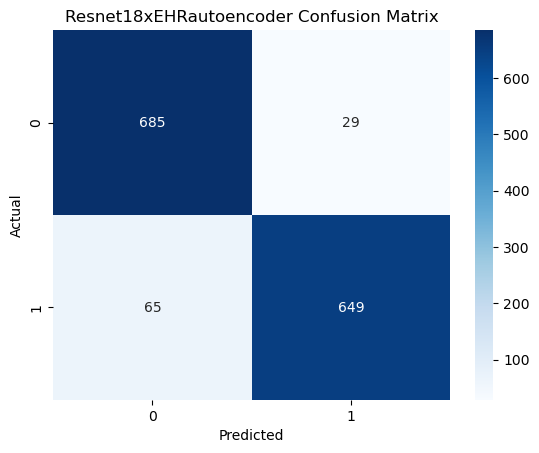

In [116]:
Resnet18xDenoiseModel_dataset = plot_metrics(Resnet18xDenoiseModel,test_idx,y_test,"Resnet18xEHRautoencoder Confusion Matrix")

In [120]:
(685+649) / (685+649+65+29)

0.9341736694677871

In [118]:
Resnet18xDenoiseModel_dataset

,race,cigsmok,gender,age,Y_true,Y_pred
0,1.0,0.0,1.0,62.0,0,1
1,1.0,1.0,1.0,60.0,1,1
2,1.0,0.0,2.0,74.0,1,1
3,1.0,0.0,1.0,73.0,1,0
4,1.0,1.0,1.0,60.0,1,1
...,...,...,...,...,...,...
1423,1.0,0.0,2.0,55.0,0,0
1424,1.0,0.0,1.0,64.0,0,0
1425,1.0,1.0,1.0,58.0,1,1
1426,1.0,1.0,2.0,72.0,0,0


Creating Metric: 100%|██████████| 1428/1428 [01:30<00:00, 15.80it/s]


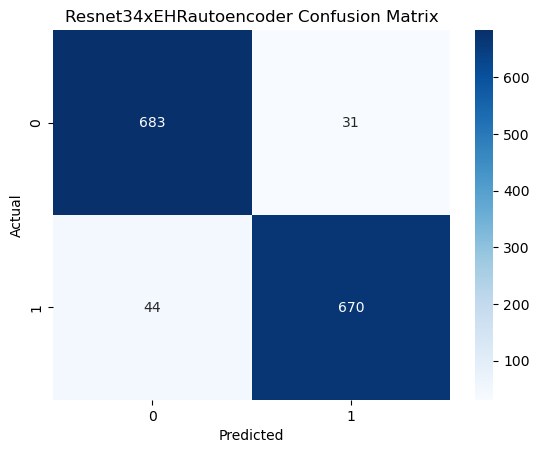

In [123]:
Resnet34xDenoiseModel_dataset = plot_metrics(Resnet34xDenoiseModel,test_idx,y_test,"Resnet34xEHRautoencoder Confusion Matrix")

In [124]:
(683+670) / (683+670+44+31)

0.9474789915966386

In [125]:
Resnet34xDenoiseModel_dataset

,race,cigsmok,gender,age,Y_true,Y_pred
0,1.0,0.0,1.0,62.0,0,1
1,1.0,1.0,1.0,60.0,1,1
2,1.0,0.0,2.0,74.0,1,1
3,1.0,0.0,1.0,73.0,1,0
4,1.0,1.0,1.0,60.0,1,1
...,...,...,...,...,...,...
1423,1.0,0.0,2.0,55.0,0,0
1424,1.0,0.0,1.0,64.0,0,0
1425,1.0,1.0,1.0,58.0,1,1
1426,1.0,1.0,2.0,72.0,0,0


#### Barplots

In [126]:
Cancer_positive18 = Resnet18xDenoiseModel_dataset[(Resnet18xDenoiseModel_dataset["Y_pred"] == 1) & (Resnet18xDenoiseModel_dataset["Y_true"] == 1)]
Cancer_positive18

,race,cigsmok,gender,age,Y_true,Y_pred
1,1.0,1.0,1.0,60.0,1,1
2,1.0,0.0,2.0,74.0,1,1
4,1.0,1.0,1.0,60.0,1,1
6,1.0,1.0,1.0,67.0,1,1
12,1.0,0.0,1.0,59.0,1,1
...,...,...,...,...,...,...
1416,1.0,0.0,1.0,59.0,1,1
1418,3.0,1.0,1.0,66.0,1,1
1419,1.0,0.0,2.0,59.0,1,1
1425,1.0,1.0,1.0,58.0,1,1


In [127]:
Cancer_positive34 = Resnet34xDenoiseModel_dataset[(Resnet34xDenoiseModel_dataset["Y_pred"] == 1) & (Resnet34xDenoiseModel_dataset["Y_true"] == 1)]
Cancer_positive34

,race,cigsmok,gender,age,Y_true,Y_pred
1,1.0,1.0,1.0,60.0,1,1
2,1.0,0.0,2.0,74.0,1,1
4,1.0,1.0,1.0,60.0,1,1
6,1.0,1.0,1.0,67.0,1,1
12,1.0,0.0,1.0,59.0,1,1
...,...,...,...,...,...,...
1416,1.0,0.0,1.0,59.0,1,1
1418,3.0,1.0,1.0,66.0,1,1
1419,1.0,0.0,2.0,59.0,1,1
1425,1.0,1.0,1.0,58.0,1,1


In [128]:
Cancer_positive34["gender"].value_counts()

gender
1.0    420
2.0    250
Name: count, dtype: int64

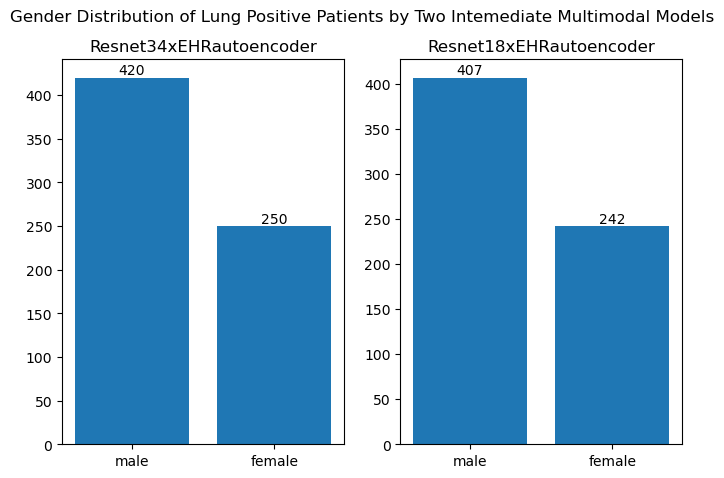

In [129]:
fig, ax = plt.subplots(1,2,figsize=(8,5))
bar1 = ax[0].bar(["male","female"],Cancer_positive34["gender"].value_counts().to_numpy())
# Add the labels
fig.suptitle("Gender Distribution of Lung Positive Patients by Two Intemediate Multimodal Models")

ax[0].bar_label(bar1)
ax[0].set_title("Resnet34xEHRautoencoder")

bar2 = ax[1].bar(["male","female"],Cancer_positive18["gender"].value_counts().to_numpy())
# Add the labels
ax[1].bar_label(bar2)
ax[1].set_title("Resnet18xEHRautoencoder")
plt.show()

[Text(0, 0, '357'), Text(0, 0, '292')]

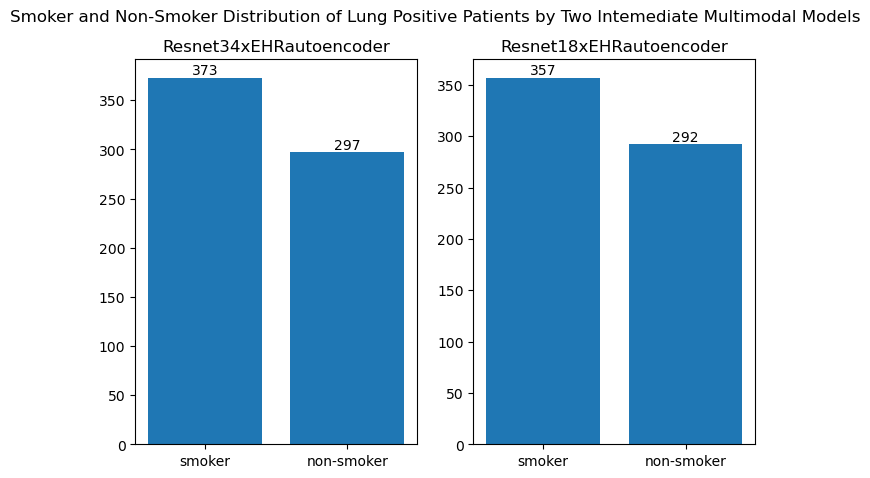

In [130]:
fig, ax = plt.subplots(1,2,figsize=(8,5))

fig.suptitle("Smoker and Non-Smoker Distribution of Lung Positive Patients by Two Intemediate Multimodal Models")

bar1 = ax[0].bar(["smoker","non-smoker"],Cancer_positive34["cigsmok"].value_counts().to_numpy())
# Add the labels
ax[0].set_title("Resnet34xEHRautoencoder")
ax[0].bar_label(bar1)

bar2 = ax[1].bar(["smoker","non-smoker"],Cancer_positive18["cigsmok"].value_counts().to_numpy())
# Add the labels
ax[1].set_title("Resnet18xEHRautoencoder")
ax[1].bar_label(bar2)




[Text(0, 0, '608'),
 Text(0, 0, '24'),
 Text(0, 0, '7'),
 Text(0, 0, '6'),
 Text(0, 0, '2'),
 Text(0, 0, '1'),
 Text(0, 0, '1')]

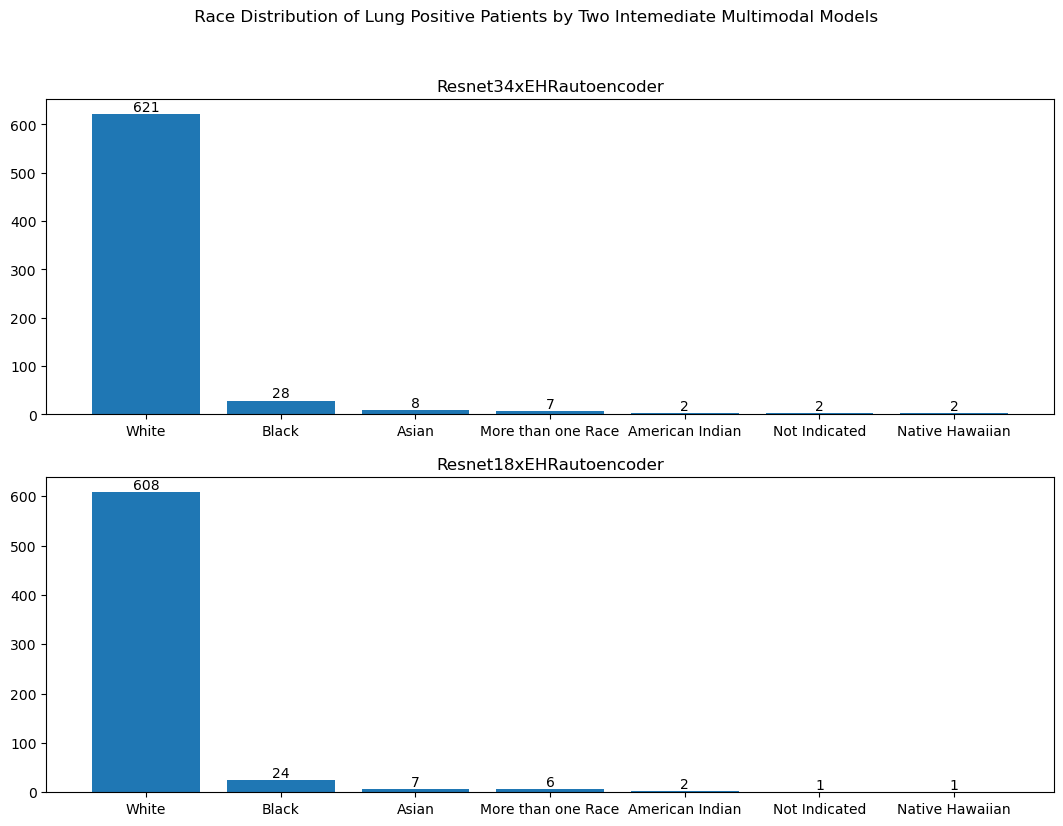

In [131]:
fig, ax = plt.subplots(2,1,figsize=(13,9))

fig.suptitle(" Race Distribution of Lung Positive Patients by Two Intemediate Multimodal Models")

bar1 = ax[0].bar(["White","Black","Asian","More than one Race","American Indian","Not Indicated","Native Hawaiian"],
        Cancer_positive34["race"].value_counts().to_numpy())
# Add the labels
ax[0].set_title("Resnet34xEHRautoencoder")
ax[0].bar_label(bar1)

bar2 = ax[1].bar(["White","Black","Asian","More than one Race","American Indian","Not Indicated","Native Hawaiian"],
        Cancer_positive18["race"].value_counts().to_numpy())
# Add the labels
ax[1].set_title("Resnet18xEHRautoencoder")
ax[1].bar_label(bar2)

In [ ]:
Final Test Metrics:
  Accuracy:  0.9475
  Precision: 0.9476
  Recall:    0.9475
  F1-Score:  0.9475
  ROC-AUC:   0.9872





Final Test Metrics:
  Accuracy:  0.9342
  Precision: 0.9353
  Recall:    0.9342
  F1-Score:  0.9341
  ROC-AUC:   0.9831





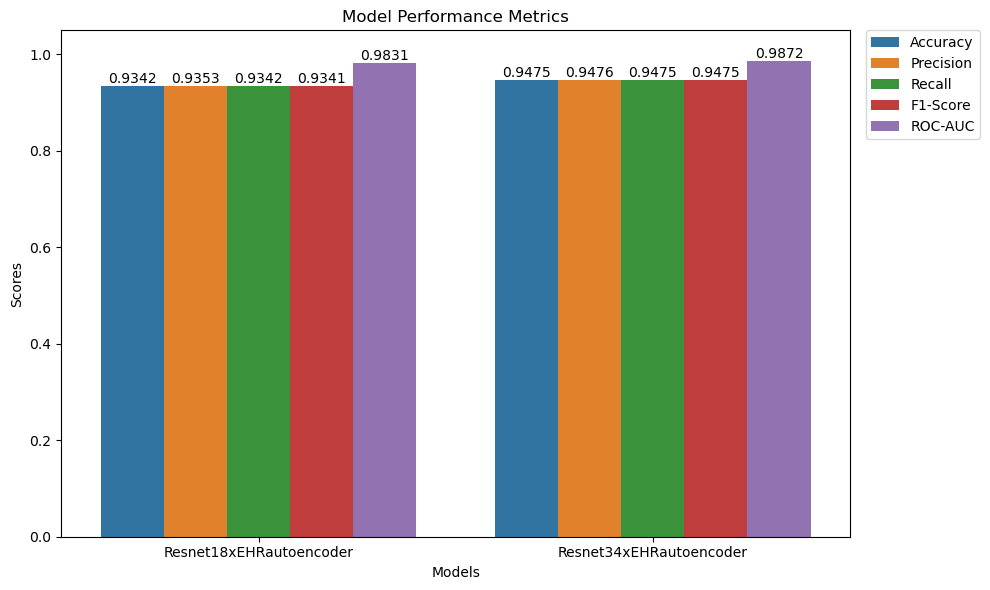

In [133]:
data = {
    'Models': ['Resnet18xEHRautoencoder','Resnet18xEHRautoencoder','Resnet18xEHRautoencoder','Resnet18xEHRautoencoder','Resnet18xEHRautoencoder',
               'Resnet34xEHRautoencoder','Resnet34xEHRautoencoder','Resnet34xEHRautoencoder','Resnet34xEHRautoencoder','Resnet34xEHRautoencoder'],
    'Metrics': ["Accuracy","Precision","Recall","F1-Score" ,"ROC-AUC","Accuracy","Precision","Recall","F1-Score" ,"ROC-AUC"],
    'Scores': [0.9342,0.9353,0.9342,0.9341,0.9831,0.9475,0.9476,0.9475,0.9475,0.9872]
}

df_grouped = pd.DataFrame(data)
plt.figure(figsize=(10, 6))

# 2. Create the grouped bar chart using seaborn
# x: The main category on the x-axis.
# y: The numerical value for the bar height.
# hue: The category that creates the groups.
ax = sns.barplot(data=df_grouped, x='Models', y='Scores', hue='Metrics')

for p in ax.patches[:-5]:
    # Get the height of the bar (which is the value)
    height = p.get_height()
    # Add the text label above the bar
    # 'height' is the y-coordinate
    # 'p.get_x() + p.get_width() / 2.' is the x-coordinate (center of the bar)
    ax.text(
        p.get_x() + p.get_width() / 2.,
        height,  # The vertical position of the text
        f'{height:.4f}', # The text to display, formatted to 2 decimal places
        ha='center',     # Horizontal alignment: center the text
        va='bottom'      # Vertical alignment: place the text below the y-coordinate
    )


# 3. Add titles and labels for clarity
plt.title('Model Performance Metrics')
plt.xlabel('Models')
plt.ylabel('Scores')
plt.ylim(0, 1.05) # Adjust y-axis limit to make space for text

# 4. Move the legend outside the plot
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

# 5. Ensure everything fits
plt.tight_layout()

# 6. Show the plot
plt.show()


## Boxplots

C:\Users\Gerard_admin\AppData\Local\Temp\ipykernel_25392\3859622994.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Cancer_positive34.loc[:,"Model"] = 'Resnet34xEHRautoencoder'
C:\Users\Gerard_admin\AppData\Local\Temp\ipykernel_25392\3859622994.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Cancer_positive18.loc[:,"Model"] = 'Resnet18xEHRautoencoder'


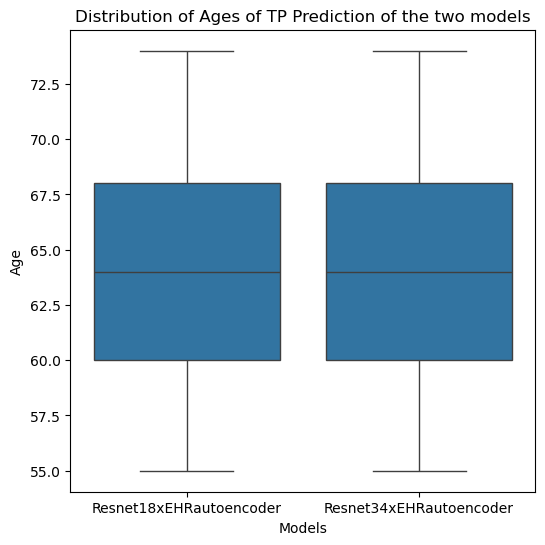

Boxplot Statistics:
                         count       mean       std   min   25%   50%   75%  \
Model                                                                         
Resnet18xEHRautoencoder  649.0  64.175652  5.473274  55.0  60.0  64.0  68.0   
Resnet34xEHRautoencoder  670.0  64.188057  5.430400  55.0  60.0  64.0  68.0   

                          max  
Model                          
Resnet18xEHRautoencoder  74.0  
Resnet34xEHRautoencoder  74.0  


In [134]:
Cancer_positive34.loc[:,"Model"] = 'Resnet34xEHRautoencoder'
Cancer_positive34_new = Cancer_positive34[['age','Model']].copy()
Cancer_positive18.loc[:,"Model"] = 'Resnet18xEHRautoencoder'
Cancer_positive18_new = Cancer_positive18[['age','Model']].copy()

boxplot_dataset = pd.concat([Cancer_positive18_new,Cancer_positive34_new])
model_stats = boxplot_dataset.groupby('Model')['age'].describe()
plt.figure(figsize=(6, 6)) # Optional: adjusts the size of the plot
sns.boxplot(x='Model', y='age', data=boxplot_dataset)

# Add title and labels for clarity
plt.title('Distribution of Ages of TP Prediction of the two models')
plt.xlabel('Models')
plt.ylabel('Age')

# Show the plot
plt.show()
print("Boxplot Statistics:")
print(model_stats)


## TABLE DATA

In [135]:
Lung_cancer_Mulimodal_table_data = pd.read_csv("Lung_Cancer_multimodal_patient_EHR.csv").iloc[:,1:-1].reset_index(drop=True)
Lung_cancer_Mulimodal_table_data

,race,cigsmok,gender,age
0,1,1,2,61
1,1,0,1,68
2,1,0,1,65
3,1,0,2,60
4,1,1,2,60
...,...,...,...,...
1142,1,0,1,57
1143,1,1,2,56
1144,1,1,2,61
1145,1,0,2,58


In [136]:
Lung_cancer_Mulimodal_table_data.__len__()

1147

In [137]:
race_counts = Lung_cancer_Mulimodal_table_data.groupby('race')['age'].count().reset_index()
race_counts = race_counts.rename(columns={'age': '# count'})


# 2. Calculate the total number of records.
total_count = len(Lung_cancer_Mulimodal_table_data)

# 3. Calculate the percentage for each race.
race_counts['percentage'] = (race_counts['# count'] / total_count) * 100

# 4. Format the percentage to two decimal places and add a '%' sign.
race_counts['percentage'] = race_counts['percentage'].map('{:.2f}%'.format)

# Display the final table with race, count, and percentage.
print("Distribution of patients by race:")
race_counts


Distribution of patients by race:


,race,# count,percentage
0,1,1056,92.07%
1,2,45,3.92%
2,3,18,1.57%
3,4,6,0.52%
4,5,5,0.44%
5,6,10,0.87%
6,7,4,0.35%
7,99,3,0.26%


In [138]:
gender_counts = Lung_cancer_Mulimodal_table_data.groupby('gender')['age'].count().reset_index()
gender_counts = gender_counts.rename(columns={'age': '# count'})


# 2. Calculate the total number of records.
total_count = len(Lung_cancer_Mulimodal_table_data)

# 3. Calculate the percentage for each race.
gender_counts['percentage'] = (gender_counts['# count'] / total_count) * 100

# 4. Format the percentage to two decimal places and add a '%' sign.
gender_counts['percentage'] = gender_counts['percentage'].map('{:.2f}%'.format)

# Display the final table with race, count, and percentage.
print("Distribution of patients by race:")
gender_counts

Distribution of patients by race:


,gender,# count,percentage
0,1,669,58.33%
1,2,478,41.67%


In [139]:
smoke_count = Lung_cancer_Mulimodal_table_data.groupby('cigsmok')['age'].count().reset_index()
smoke_count = smoke_count.rename(columns={'age': '# count'})


# 2. Calculate the total number of records.
total_count = len(Lung_cancer_Mulimodal_table_data)

# 3. Calculate the percentage for each race.
smoke_count['percentage'] = (smoke_count['# count'] / total_count) * 100

# 4. Format the percentage to two decimal places and add a '%' sign.
smoke_count['percentage'] = smoke_count['percentage'].map('{:.2f}%'.format)

# Display the final table with race, count, and percentage.
print("Distribution of patients by race:")
smoke_count

Distribution of patients by race:


,cigsmok,# count,percentage
0,0,575,50.13%
1,1,572,49.87%


In [140]:
Lung_cancer_Mulimodal_table_data['age'].describe()

count    1147.000000
mean       62.489102
std         5.271562
min        55.000000
25%        58.000000
50%        62.000000
75%        66.000000
max        74.000000
Name: age, dtype: float64

In [141]:
lung_cancer_age_data = []
for item  in Lung_cancer_Mulimodal_table_data['age']:
    if item <=58:
        lung_cancer_age_data.append("<=58")
    elif (item > 58) and (item < 61):
        lung_cancer_age_data.append("58>n<61")
    elif (item >=61) and (item < 65):
        lung_cancer_age_data.append("61>=n<65")
    elif item >=65:
        lung_cancer_age_data.append(">=65")


In [92]:
lung_cancer_age_data.__len__()

1147

In [93]:
Lung_cancer_Mulimodal_table_data.loc[:,"Age_c"] = lung_cancer_age_data

In [103]:
Age_c_count = Lung_cancer_Mulimodal_table_data.groupby('Age_c')['age'].count().reset_index()
Age_c_count = Age_c_count.rename(columns={'age': '# count'})


# 2. Calculate the total number of records.
total_count = len(Lung_cancer_Mulimodal_table_data)

# 3. Calculate the percentage for each race.
Age_c_count['percentage'] = (Age_c_count['# count'] / total_count) * 100

# 4. Format the percentage to two decimal places and add a '%' sign.
Age_c_count['percentage'] = Age_c_count['percentage'].map('{:.2f}%'.format)

# Display the final table with race, count, and percentage.
print("Distribution of patients by race:")
Age_c_count

Distribution of patients by race:


,Age_c,# count,percentage
0,58>n<61,169,14.73%
1,61>=n<65,269,23.45%
2,<=58,316,27.55%
3,>=65,393,34.26%
